In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
from functools import partial
from pathlib import Path
import pandas as pd
from Utils.direction_comparison import (
    ego_coordinates, gen_overlap_list, peak_angles,
    sorted_by_peak, plot_profiles, plot_comparison_heatmaps as compare_heatmaps,
    load_rf_profiles, load_hd_profiles,
)
from Utils.plotting import apply_light_plot_style, plot_direction_comparison
from Utils.statistic_utils import compare_direction_angles
apply_light_plot_style()


In [2]:
base_dir = Path("/mnt/senzailab/Kai/#Recording/m20")
date = 260918
hd_session_id = 9
rf_session_id = 2
probes = ("A", )

hd_bin_count = 30
hd_smoothing_deg = 3.0
rf_smoothing_bins = 1.5
rf_response_window_s = (0.0, 0.2)
density_bin_count = 12
statistics_permutations = 10_000
statistics_seed = 1


session_dir = base_dir / str(date)
hd_session = session_dir / f"{date}_{hd_session_id}"
rf_session = session_dir / f"{date}_{rf_session_id}"


In [3]:
rf_profile_tables, hd_profile_tables = [], []
for probe in probes:
    rfmap_file = (
        rf_session / "data/rfmapping/good/-100_400_1ms" / f"Probe{probe}"
        / f"regular_unitsSpikeCounts_{rf_session.name}.rfmap"
    )
    hd_file = hd_session / "data/tuning_curves" / f"Probe{probe}" / "tuning_curves.tc"

    rf_profile_tables.append(load_rf_profiles(
        rfmap_file, probe=probe, window=rf_response_window_s,
        smoothing_bins=rf_smoothing_bins,
    )[0])
    hd_profile_tables.append(load_hd_profiles(
        hd_file, probe=probe, bins=hd_bin_count, smoothing_deg=hd_smoothing_deg,
    ))

rf_profiles = pd.concat(rf_profile_tables)
hd_profiles = pd.concat(hd_profile_tables)

rf_unit_ids = rf_profiles.index.get_level_values("unit_id").to_numpy()
hd_unit_ids = hd_profiles.index.get_level_values("unit_id").to_numpy()


In [4]:
profile_by_type = {"HD": hd_profiles, "RF": rf_profiles}
plot_comparison_heatmaps = partial(compare_heatmaps, profile_by_type)

def shared_unit_keys(first, second):
    return gen_overlap_list(profile_by_type[first].index, profile_by_type[second].index)

def analyze_pair(first, second):
    units = shared_unit_keys(first, second)
    reference = peak_angles(profile_by_type[first], units)
    matched = peak_angles(profile_by_type[second], units)
    statistics = compare_direction_angles(
        reference, matched, n_permutations=statistics_permutations, random_seed=statistics_seed,
    )
    plot_direction_comparison(
        reference, matched,
        statistics, reference_label=first, matched_label=second, angle_ticks=ego_coordinates["ticks"],
        reference_ticklabels=ego_coordinates["ticklabels"],
        matched_ticklabels=ego_coordinates["ticklabels"], density_bin_count=density_bin_count,
    )
    return statistics

{"units": {name: len(table) for name, table in profile_by_type.items()},
 "shared_units": {"HD-RF": len(shared_unit_keys("HD", "RF"))}}


{'units': {'HD': 59, 'RF': 30}, 'shared_units': {'HD-RF': 13}}

## All profiles, sorted by their own peaks

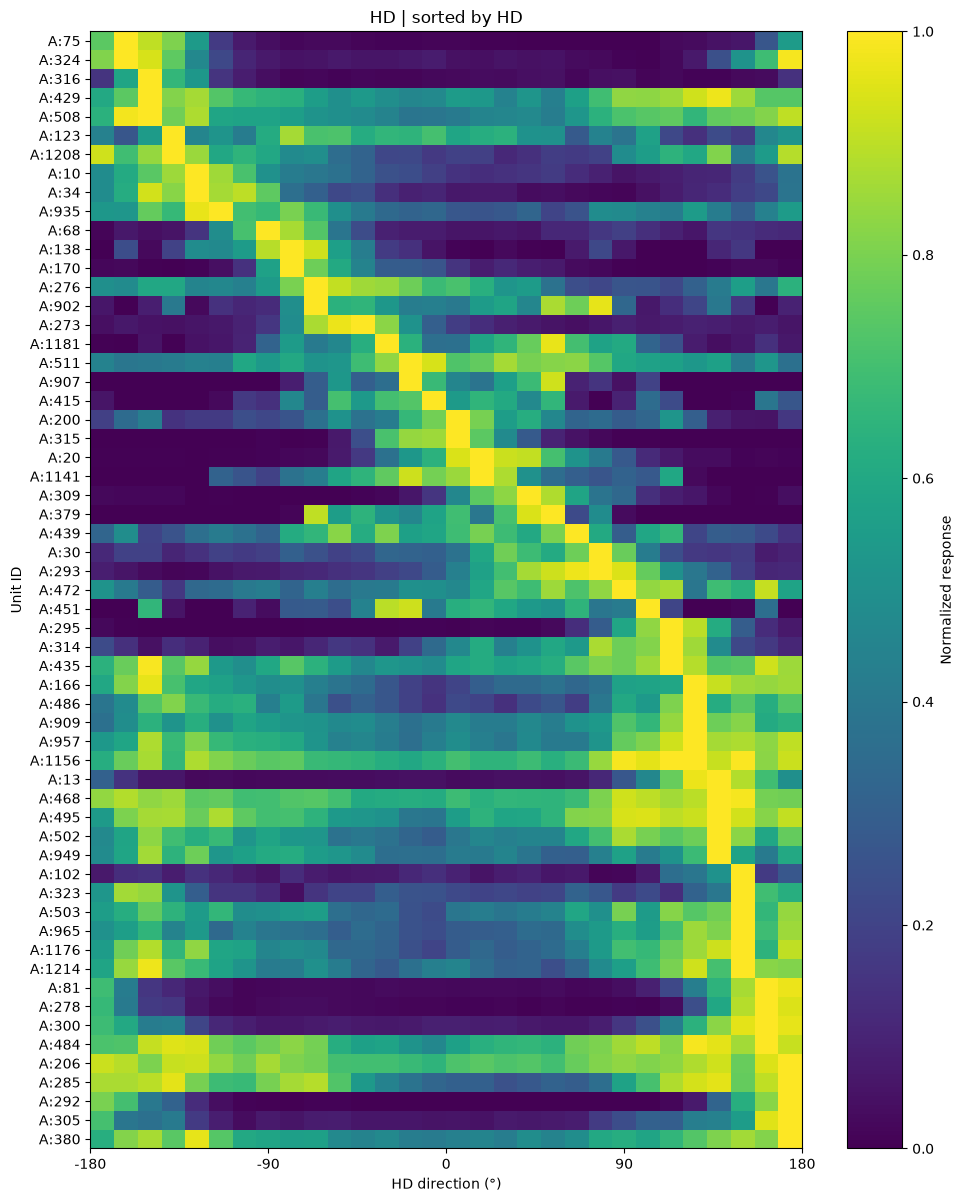

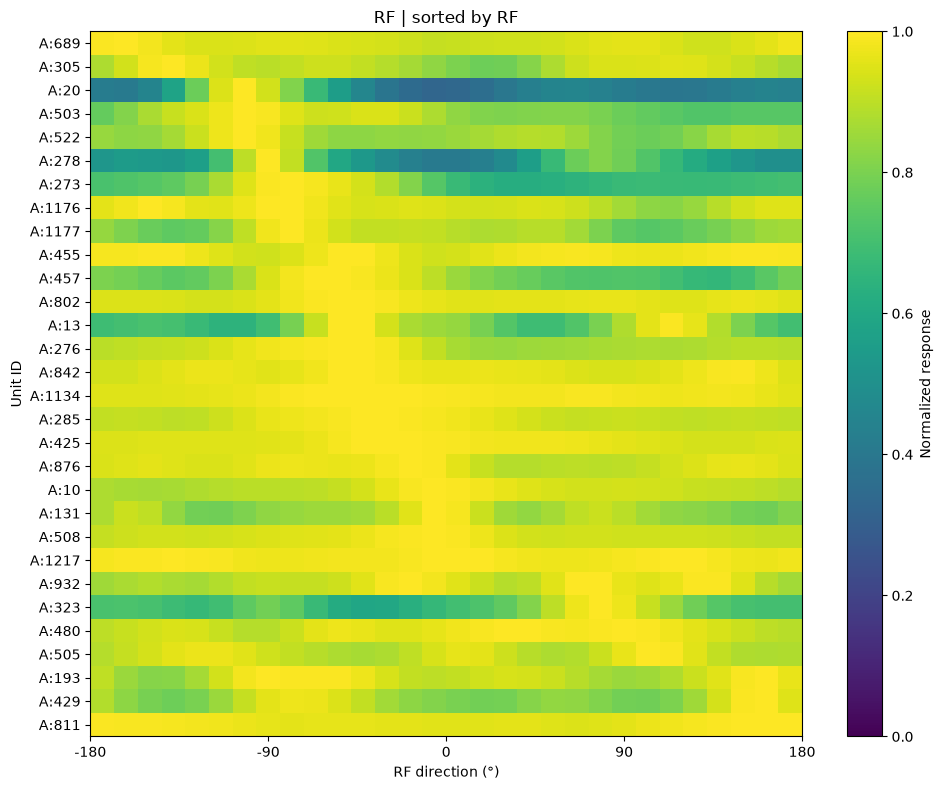

In [5]:
for name, profiles in profile_by_type.items():
    order = sorted_by_peak(profiles, profiles.index)
    plot_profiles(profiles, order, name)


## HD–RF

Each call plots sorted_by and apply_to with the same shared-unit rows, sorted by the sorted_by peak. The two calls explicitly show both sorting directions (four heatmaps). Statistics use HD on x and RF on y.


----- Based on HD -----


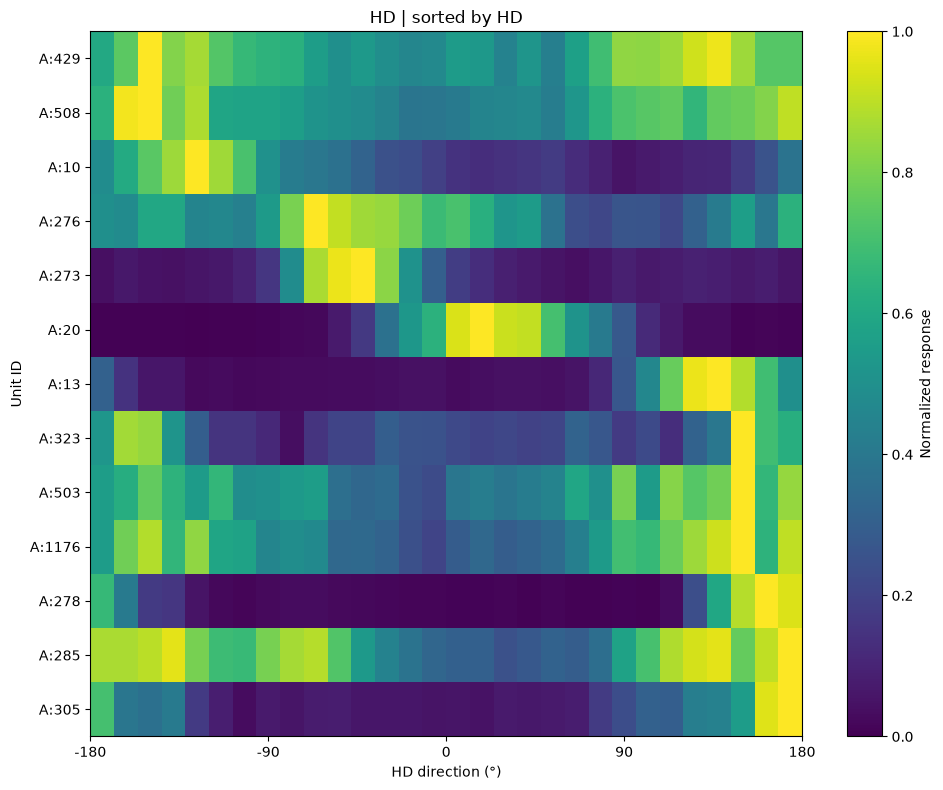

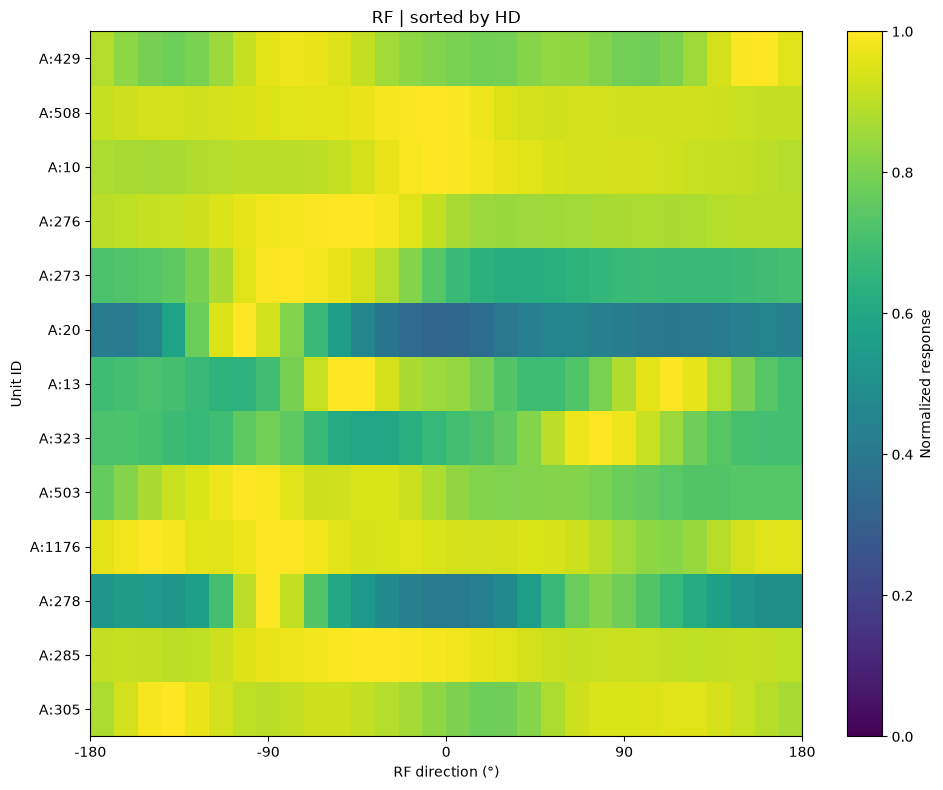

----- Based on RF -----


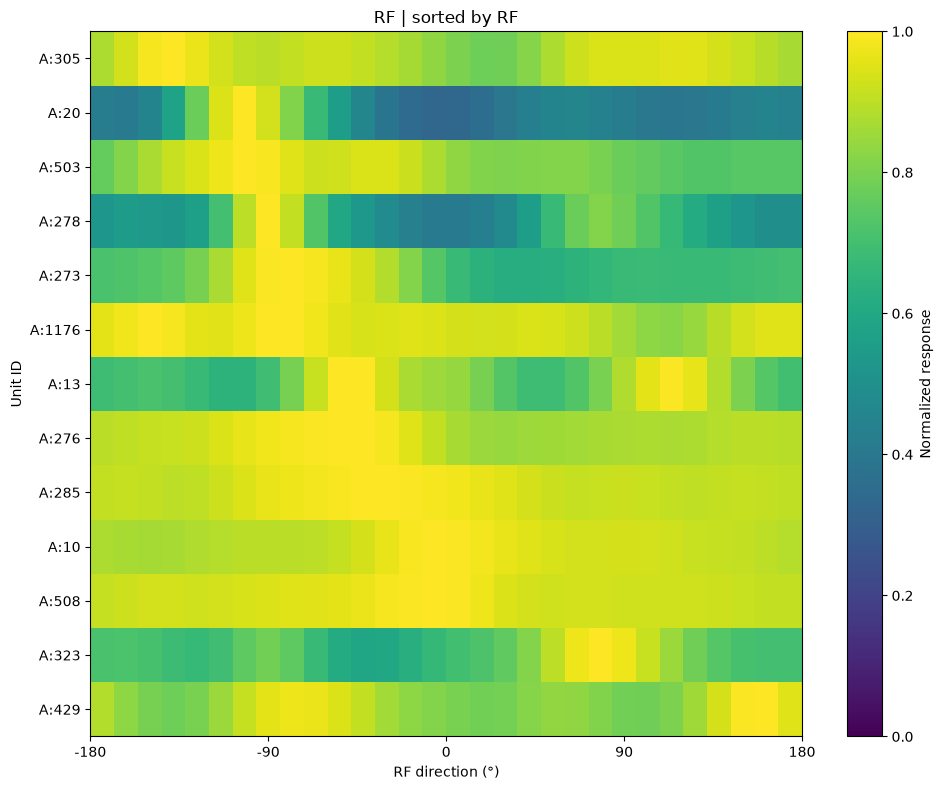

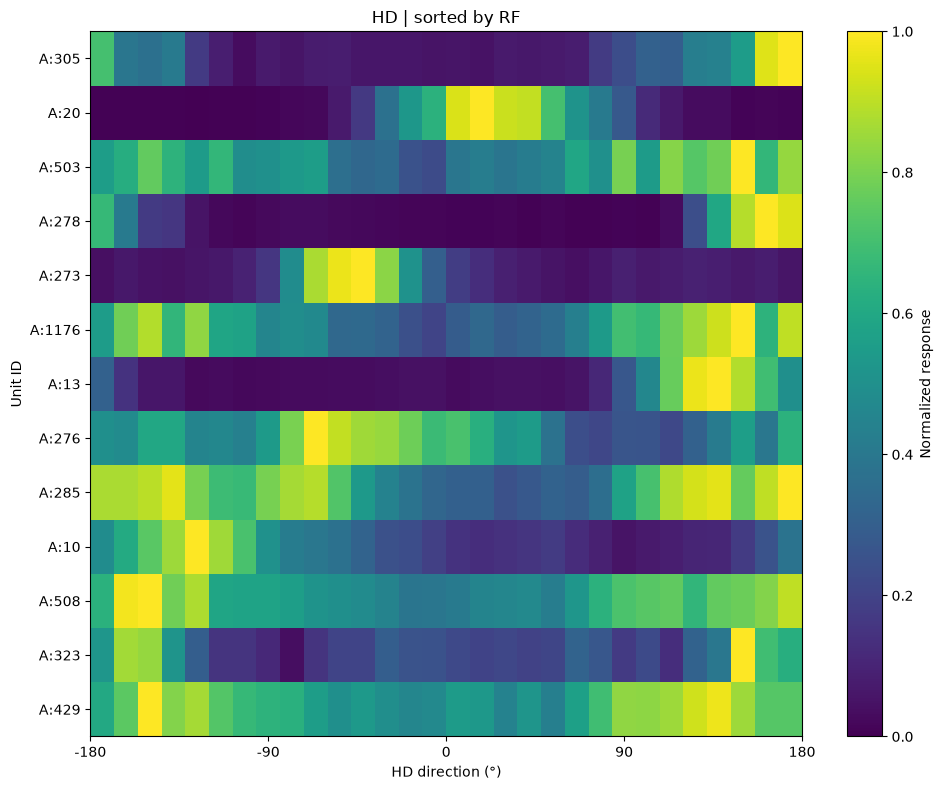

{'order': [('A', 305),
  ('A', 20),
  ('A', 503),
  ('A', 278),
  ('A', 273),
  ('A', 1176),
  ('A', 13),
  ('A', 276),
  ('A', 285),
  ('A', 10),
  ('A', 508),
  ('A', 323),
  ('A', 429)],
 'reference_peak_deg': array([-138., -102., -102.,  -90.,  -78.,  -78.,  -42.,  -42.,  -30.,
          -6.,   -6.,   78.,  162.]),
 'matched_peak_deg': array([ 174.,   18.,  150.,  162.,  -42.,  150.,  138.,  -66.,  174.,
        -126., -150.,  150., -150.]),
 'peak_sum_deg': array([  36.,  -84.,   48.,   72., -120.,   72.,   96., -108.,  144.,
        -132., -156., -132.,   12.]),
 'offset_deg': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'matched_offset_deg': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'mode': 'native',
 'figures': [(<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'RF | sorted by RF'}, xlabel='RF direction (°)', ylabel='Unit ID'>),
  (<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'HD | sorted by RF'}, xlabel='HD d

In [6]:
print("----- Based on HD -----")
plot_comparison_heatmaps(sorted_by="HD", apply_to="RF")
print("----- Based on RF -----")
plot_comparison_heatmaps(sorted_by="RF", apply_to="HD")


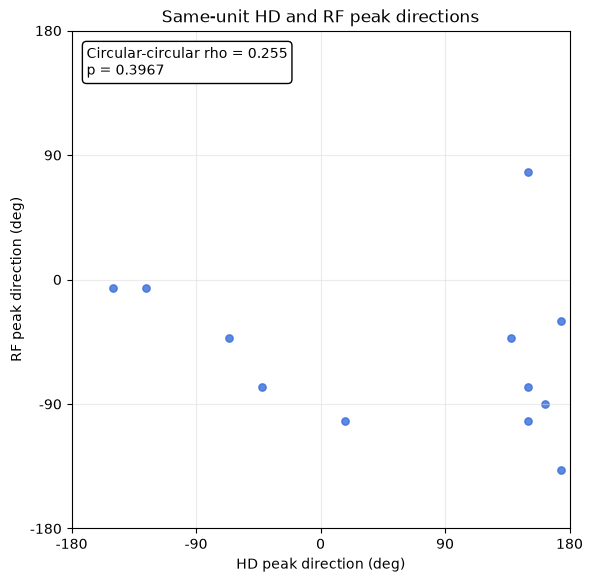

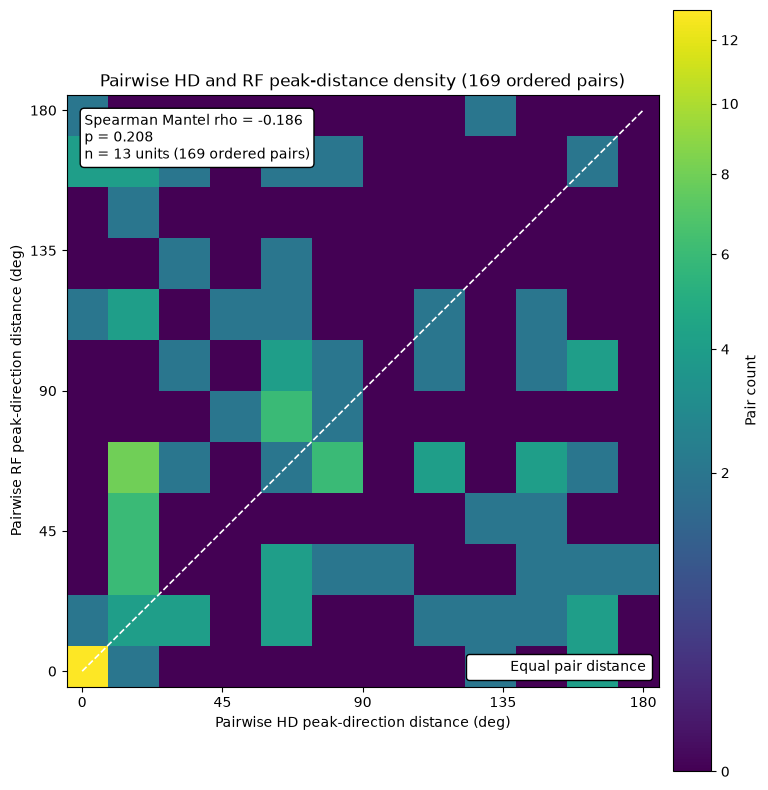

{'same_unit': {'circular_correlation_rho': 0.2546072229470164,
  'permutation_p': 0.39666033396660333,
  'one_to_one_offset_deg': 123.18256051764453,
  'alignment_resultant': 0.23048263492245719,
  'unit_count': 13},
 'pairwise': {'spearman_mantel_rho': -0.18571623963501785,
  'permutation_p': 0.207979202079792,
  'unit_count': 13,
  'ordered_pair_count': 169}}

In [7]:
hd_rf_statistics = analyze_pair("HD", "RF")
hd_rf_statistics